# PCB Defect Detection — YOLOv8 Comparative Study

**Dataset Available**: https://www.kaggle.com/datasets/akhatova/pcb-defects

**Pipeline:** Setup → Download → XML→YOLO Conversion → EDA → Training → Evaluation → Inference

**Annotation format:** Pascal VOC XML с `<bndbox>` (абсолютные пиксельные координаты xmin/ymin/xmax/ymax).

**Conversion to YOLO:** `class_idx cx cy w h` 0-based class index, all values normalized 0–1.

---

## 1. Environment Setup

In [1]:
# !pip install --upgrade ultralytics seaborn PyYAML tqdm -q

import os, shutil, random
import xml.etree.ElementTree as ET
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import yaml
from PIL import Image
from tqdm import tqdm

import torch
from ultralytics import YOLO

In [2]:
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True

DEVICE = 0 if torch.cuda.is_available() else 'cpu'
random.seed(42)
np.random.seed(42)

PyTorch: 2.10.0+cu126
CUDA available: True
GPU: NVIDIA GeForce RTX 3060


In [25]:
CLASS_NAMES = [
    'missing_hole',
    'mouse_bite',
    'open_circuit',
    'short',
    'spur',
    'spurious_copper',
]
NUM_CLASSES = len(CLASS_NAMES)

XML_NAME_TO_IDX = {name: i for i, name in enumerate(CLASS_NAMES)}

FOLDER_TO_IDX = {
    'Missing_hole':    0,
    'Mouse_bite':      1,
    'Open_circuit':    2,
    'Short':           3,
    'Spur':            4,
    'Spurious_copper': 5,
}

CLASS_COLORS = {
    'missing_hole':    '#e74c3c',
    'mouse_bite':      '#3498db',
    'open_circuit':    '#2ecc71',
    'short':           '#f39c12',
    'spur':            '#DEC347',
    'spurious_copper': '#1abc9c',
}

print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')

Classes (6): ['missing_hole', 'mouse_bite', 'open_circuit', 'short', 'spur', 'spurious_copper']


## 2. Download Dataset

In [4]:
RAW_DIR = Path('PCB_DATASET')

print('images/    :', sorted(os.listdir(RAW_DIR / 'images')))
print('Annotations:', sorted(os.listdir(RAW_DIR / 'Annotations')))

images/    : ['Missing_hole', 'Mouse_bite', 'Open_circuit', 'Short', 'Spur', 'Spurious_copper']
Annotations: ['Missing_hole', 'Mouse_bite', 'Open_circuit', 'Short', 'Spur', 'Spurious_copper']


## 3. Parse XML Annotations

Each XML file is Pascal VOC format. One image can contain **multiple** `<object>` entries.

```xml
<object>
  <n>mouse_bite</n>
  <bndbox>
    <xmin>1018</xmin>  <ymin>1281</ymin>
    <xmax>1120</xmax>  <ymax>1340</ymax>
  </bndbox>
</object>
```

In [5]:
def parse_voc_xml(xml_path: Path) -> dict:
    """
    Parse a single Pascal VOC XML file.
    Returns dict: filename, width, height, objects (list of dicts).
    """
    tree = ET.parse(xml_path)
    root = tree.getroot()

    size  = root.find('size')
    W = int(size.find('width').text)
    H = int(size.find('height').text)
    filename = root.find('filename').text

    objects = []
    for obj in root.findall('object'):
        name_el = obj.find('name')
        if name_el is None:
            name_el = obj.find('n')
        if name_el is None:
            print(f'  [!] Нет тега имени класса в {xml_path.name}, пропускаем объект')
            continue
        name = name_el.text.strip().lower()
        bb   = obj.find('bndbox')
        xmin = int(float(bb.find('xmin').text))
        ymin = int(float(bb.find('ymin').text))
        xmax = int(float(bb.find('xmax').text))
        ymax = int(float(bb.find('ymax').text))
        objects.append(dict(name=name, xmin=xmin, ymin=ymin, xmax=xmax, ymax=ymax))

    return dict(filename=filename, width=W, height=H, objects=objects)


sample_xml = next((RAW_DIR / 'Annotations' / 'Mouse_bite').glob('*.xml'))
parsed = parse_voc_xml(sample_xml)

print('filename :', parsed['filename'])
print(f'size : {parsed["width"]} x {parsed["height"]}')
print('objects :')
for o in parsed['objects']:
    print(f'  {o}')

filename : 01_mouse_bite_01.jpg
size : 3034 x 1586
objects :
  {'name': 'mouse_bite', 'xmin': 1518, 'ymin': 913, 'xmax': 1547, 'ymax': 958}
  {'name': 'mouse_bite', 'xmin': 2020, 'ymin': 1260, 'xmax': 2046, 'ymax': 1302}
  {'name': 'mouse_bite', 'xmin': 2595, 'ymin': 888, 'xmax': 2620, 'ymax': 920}


## 4. Convert Pascal VOC → YOLO Format + Train/Val/Test Split

**YOLO label format** (one line per object):
```
class_idx  cx  cy  w  h
```
All values normalized to [0, 1] relative to image dimensions.

**Split:** 70% train / 15% val / 15% test (**стратифицированный** по классам, seed=42)

In [6]:
def voc_to_yolo_line(obj: dict, W: int, H: int):
    """Convert one VOC object to a YOLO label line. Returns None if unknown class."""
    cls_idx = XML_NAME_TO_IDX.get(obj['name'])
    if cls_idx is None:
        print(f'  [!] Unknown class: {obj["name"]}')
        return None

    xmin = max(0, min(obj['xmin'], W))
    xmax = max(0, min(obj['xmax'], W))
    ymin = max(0, min(obj['ymin'], H))
    ymax = max(0, min(obj['ymax'], H))

    if xmax <= xmin or ymax <= ymin:
        return None

    cx = (xmin + xmax) / 2 / W
    cy = (ymin + ymax) / 2 / H
    bw = (xmax - xmin) / W
    bh = (ymax - ymin) / H

    return f'{cls_idx} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}'


def build_yolo_dataset(
    raw_dir: Path,
    out_dir: Path,
    train_ratio: float = 0.70,
    val_ratio:   float = 0.15,
    seed: int = 42,
) -> None:
    """Convert PCB_DATASET to YOLO structure with STRATIFIED train/val/test splits."""
    random.seed(seed)

    anno_root  = raw_dir / 'Annotations'
    image_root = raw_dir / 'images'

    all_train, all_val, all_test = [], [], []
    stats = defaultdict(int)

    for folder_name, cls_idx in FOLDER_TO_IDX.items():
        xml_dir = anno_root  / folder_name
        img_dir = image_root / folder_name

        if not xml_dir.exists():
            print(f'[!] Missing annotation folder: {xml_dir}')
            continue

        class_pairs = []
        for xml_path in sorted(xml_dir.glob('*.xml')):
            stem = xml_path.stem
            img_path = None
            for ext in ['.jpg', '.JPG', '.jpeg', '.png']:
                candidate = img_dir / (stem + ext)
                if candidate.exists():
                    img_path = candidate
                    break
            if img_path is None:
                print(f'  [!] No image for {xml_path.name}')
                continue
            class_pairs.append((xml_path, img_path))
            stats[folder_name] += 1

        random.shuffle(class_pairs)
        n = len(class_pairs)
        n_train = int(n * train_ratio)
        n_val   = int(n * val_ratio)
        all_train.extend(class_pairs[:n_train])
        all_val.extend(class_pairs[n_train : n_train + n_val])
        all_test.extend(class_pairs[n_train + n_val:])

    total = len(all_train) + len(all_val) + len(all_test)
    print(f'Total annotated images found: {total}')
    for k, v in stats.items():
        print(f'  {k}: {v}')

    splits = {'train': all_train, 'val': all_val, 'test': all_test}

    skipped = 0
    for split, pairs in splits.items():
        img_out = out_dir / split / 'images'
        lbl_out = out_dir / split / 'labels'
        img_out.mkdir(parents=True, exist_ok=True)
        lbl_out.mkdir(parents=True, exist_ok=True)

        for xml_path, img_path in pairs:
            try:
                parsed = parse_voc_xml(xml_path)
            except Exception as e:
                print(f'  [!] Failed to parse {xml_path.name}: {e}')
                skipped += 1
                continue

            W, H = parsed['width'], parsed['height']

            lines = []
            for obj in parsed['objects']:
                line = voc_to_yolo_line(obj, W, H)
                if line:
                    lines.append(line)

            if not lines:
                print(f'  [!] Нет валидных аннотаций: {xml_path.name}, пропускаем')
                skipped += 1
                continue

            shutil.copy(img_path, img_out / img_path.name)
            (lbl_out / (img_path.stem + '.txt')).write_text('\n'.join(lines))

        print(f'  {split:5s}: {len(pairs)} images written')

    if skipped:
        print(f'  [!] Skipped {skipped} files with errors')


DATA_DIR = Path('pcb_yolo')
if DATA_DIR.exists():
    shutil.rmtree(DATA_DIR)

print('Converting Pascal VOC XML → YOLO...')
build_yolo_dataset(RAW_DIR, DATA_DIR)

Converting Pascal VOC XML → YOLO...
Total annotated images found: 693
  Missing_hole: 115
  Mouse_bite: 115
  Open_circuit: 116
  Short: 116
  Spur: 115
  Spurious_copper: 116
  train: 483 images written
  val  : 102 images written
  test : 108 images written


In [8]:
DATA_YAML = DATA_DIR / 'data.yaml'

cfg = {
    'path':  str(DATA_DIR.resolve()).replace('\\', '/'),
    'train': 'train/images',
    'val':   'val/images',
    'test':  'test/images',
    'nc':    NUM_CLASSES,
    'names': CLASS_NAMES,
}
with open(DATA_YAML, 'w') as f:
    yaml.dump(cfg, f, default_flow_style=False, allow_unicode=True)

In [12]:
print('Split verification:')
for split in ['train', 'val', 'test']:
    ni = len(list((DATA_DIR / split / 'images').glob('*')))
    nl = len(list((DATA_DIR / split / 'labels').glob('*.txt')))
    print(f'  {split:5s}  images={ni}  labels={nl}')

Split verification:
  train  images=483  labels=483
  val    images=102  labels=102
  test   images=108  labels=108


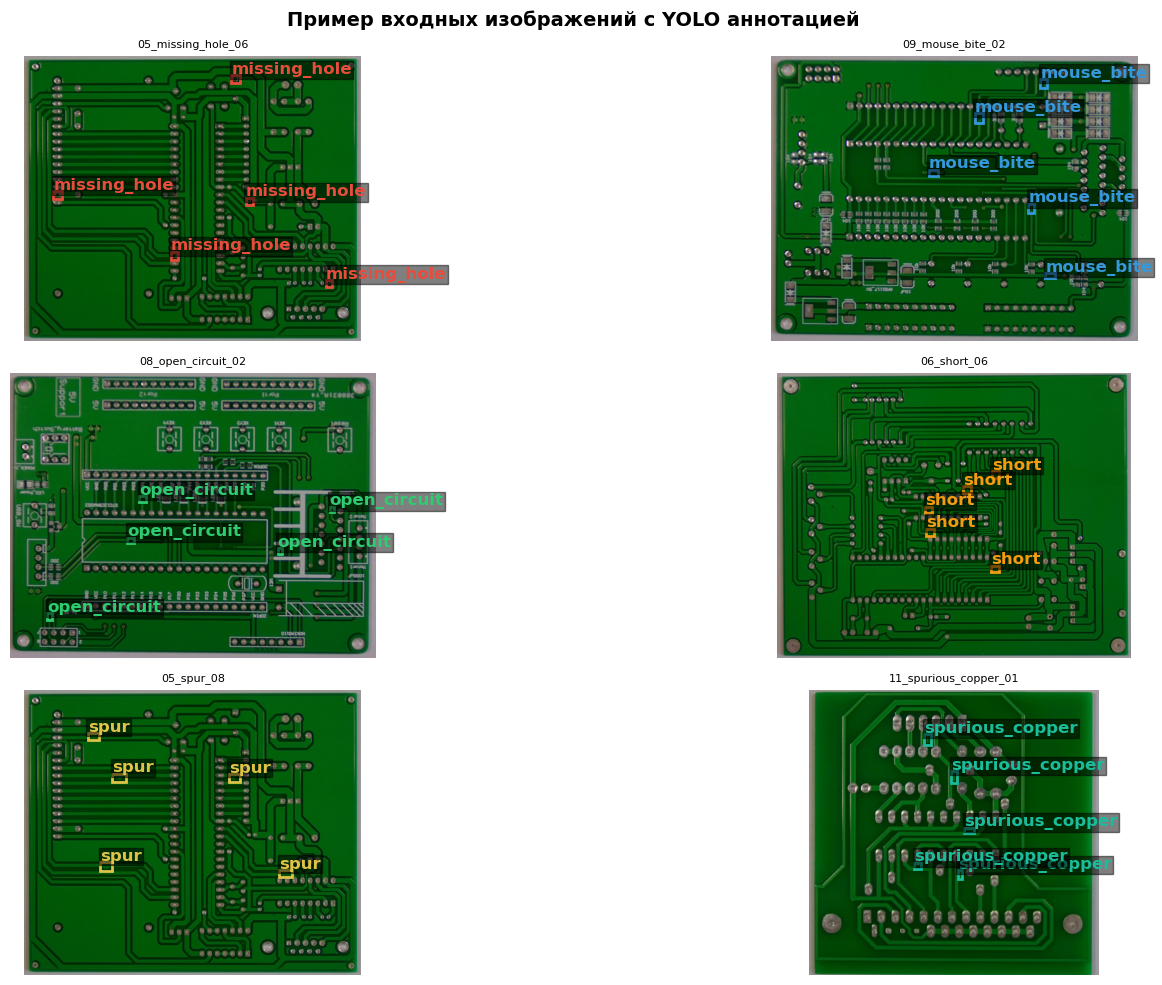

In [46]:
def draw_yolo_boxes(ax, img: Image.Image, label_path: Path) -> None:
    W, H = img.size
    ax.imshow(img)
    if label_path.exists():
        for line in open(label_path):
            p = line.strip().split()
            if len(p) == 5:
                idx = int(p[0])
                cx, cy, bw, bh = map(float, p[1:])
                x1 = (cx - bw/2) * W
                y1 = (cy - bh/2) * H
                cls_name = CLASS_NAMES[idx]
                color = CLASS_COLORS[cls_name]
                ax.add_patch(mpatches.Rectangle(
                    (x1, y1), bw*W, bh*H,
                    linewidth=2, edgecolor=color, facecolor='none'
                ))
                ax.text(x1, y1 - 10, cls_name,
                        color=color, fontsize=12, fontweight='bold',
                        bbox=dict(fc='black', alpha=0.5, pad=1))
    ax.axis('off')


train_imgs = []
for ext in ['*.jpg', '*.JPG', '*.jpeg']:
    train_imgs.extend((DATA_DIR / 'train' / 'images').glob(ext))
# sample_imgs = random.sample(train_imgs, min(6, len(train_imgs)))

grouped_paths = {class_name: [] for class_name in CLASS_NAMES}
for path in train_imgs:
    path_str = str(path)
    for class_name in CLASS_NAMES:
        if f'_{class_name}_' in path_str or path_str.endswith(f'_{class_name}.jpg'):
            grouped_paths[class_name].append(path)
            break


sample_imgs = []
for class_name, paths_list in grouped_paths.items():
    if paths_list:
        sample_imgs.append(random.choice(paths_list))

fig, axes = plt.subplots(3, 2, figsize=(18, 10))
fig.suptitle('Пример входных изображений с YOLO аннотацией', 
             fontsize=14, fontweight='bold')

for ax, img_path in zip(axes.flatten(), sample_imgs):
    lbl = DATA_DIR / 'train' / 'labels' / (img_path.stem + '.txt')
    img = Image.open(img_path).convert('RGB')
    draw_yolo_boxes(ax, img, lbl)
    ax.set_title(img_path.stem, fontsize=8)

plt.tight_layout()
plt.savefig('converted_samples.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Exploratory Data Analysis (EDA)

In [ ]:
def count_annotations(labels_dir: Path) -> pd.DataFrame:
    counts = defaultdict(int)
    for lf in labels_dir.glob('*.txt'):
        for line in open(lf):
            line = line.strip()
            if line:
                counts[CLASS_NAMES[int(line.split()[0])]] += 1
    return pd.DataFrame([
        {'class': k, 'count': v} for k, v in counts.items()
    ])

train_df = count_annotations(DATA_DIR / 'train' / 'labels')
val_df   = count_annotations(DATA_DIR / 'val'   / 'labels')
test_df  = count_annotations(DATA_DIR / 'test'  / 'labels')

combined = (
    train_df.rename(columns={'count': 'train'})
    .merge(val_df.rename(columns={'count': 'val'}),   on='class')
    .merge(test_df.rename(columns={'count': 'test'}), on='class')
)
combined['total'] = combined[['train','val','test']].sum(axis=1)
print(combined.sort_values('total', ascending=False).to_string(index=False))

          class  train  val  test  total
spurious_copper    349   72    82    503
   missing_hole    347   76    74    497
     mouse_bite    339   76    77    492
          short    341   72    78    491
           spur    338   73    77    488
   open_circuit    337   73    72    482


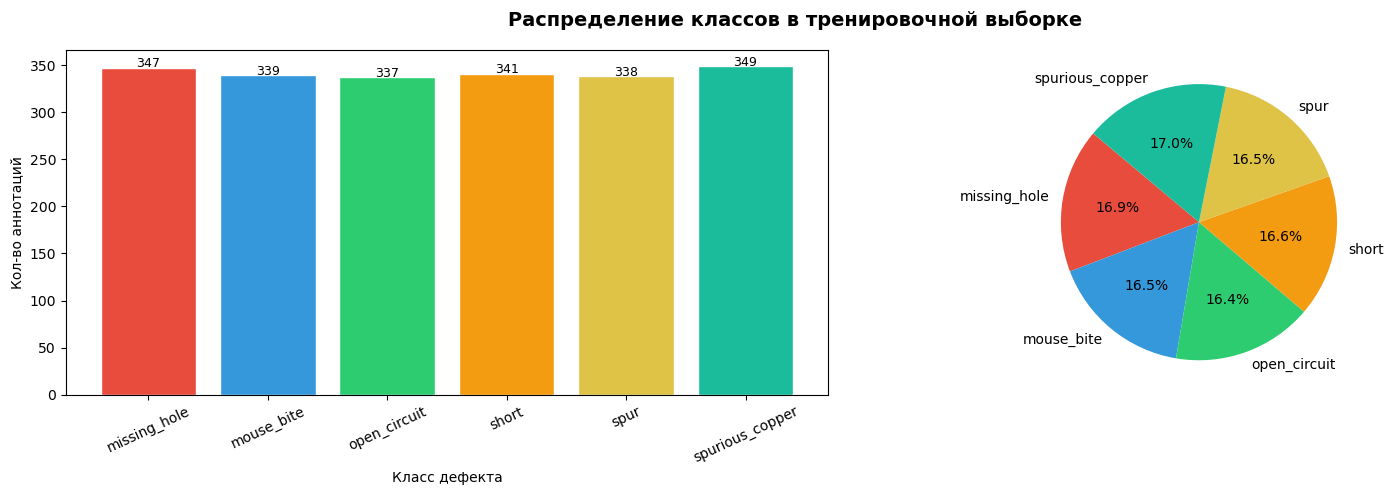

In [ ]:
colors = [CLASS_COLORS[c] for c in CLASS_NAMES]
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Распределение классов в тренировочной выборке',
              fontsize=14, fontweight='bold')

td = train_df.set_index('class').reindex(CLASS_NAMES).reset_index()

bars = axes[0].bar(td['class'], td['count'], color=colors, edgecolor='white')
axes[0].set_xlabel('Класс дефекта')
axes[0].set_ylabel('Кол-во аннотаций')
axes[0].tick_params(axis='x', rotation=25)
for bar, cnt in zip(bars, td['count']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5, str(int(cnt)), ha='center', fontsize=9)

axes[1].pie(td['count'], labels=td['class'],
            autopct='%1.1f%%', colors=colors, startangle=140)
plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

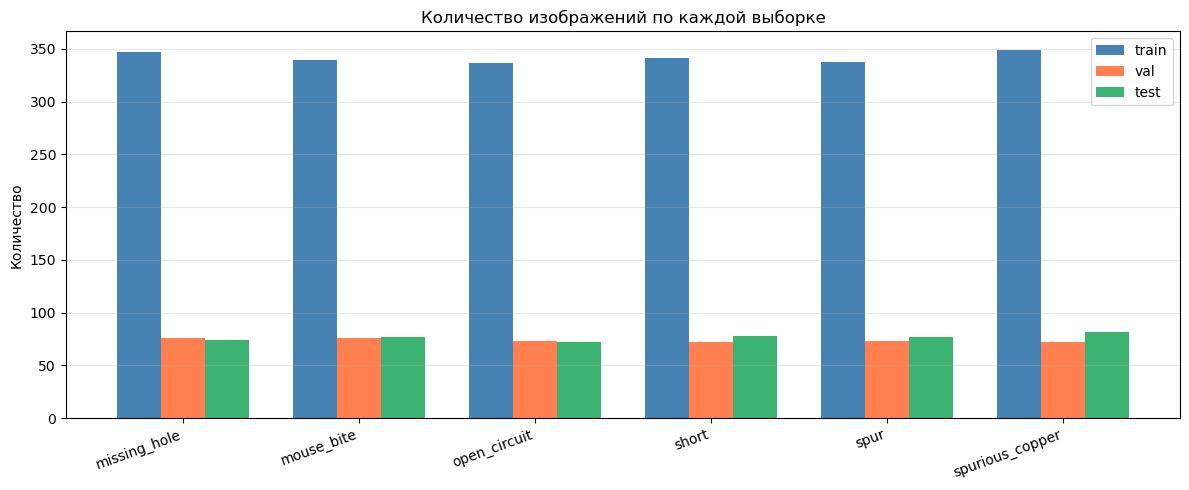

In [ ]:
x = np.arange(NUM_CLASSES)
w = 0.25
cd = combined.set_index('class').reindex(CLASS_NAMES)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w, cd['train'], width=w, label='train', color='steelblue')
ax.bar(x,     cd['val'],   width=w, label='val',   color='coral')
ax.bar(x + w, cd['test'],  width=w, label='test',  color='mediumseagreen')
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=20, ha='right')
ax.set_ylabel('Количество')
ax.set_title('Количество изображений по каждой выборке')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('eda_splits.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\kvard\AppData\Local\Temp\ipykernel_25712\3881460805.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=bbox_df, x='class', y='area', ax=axes[2],


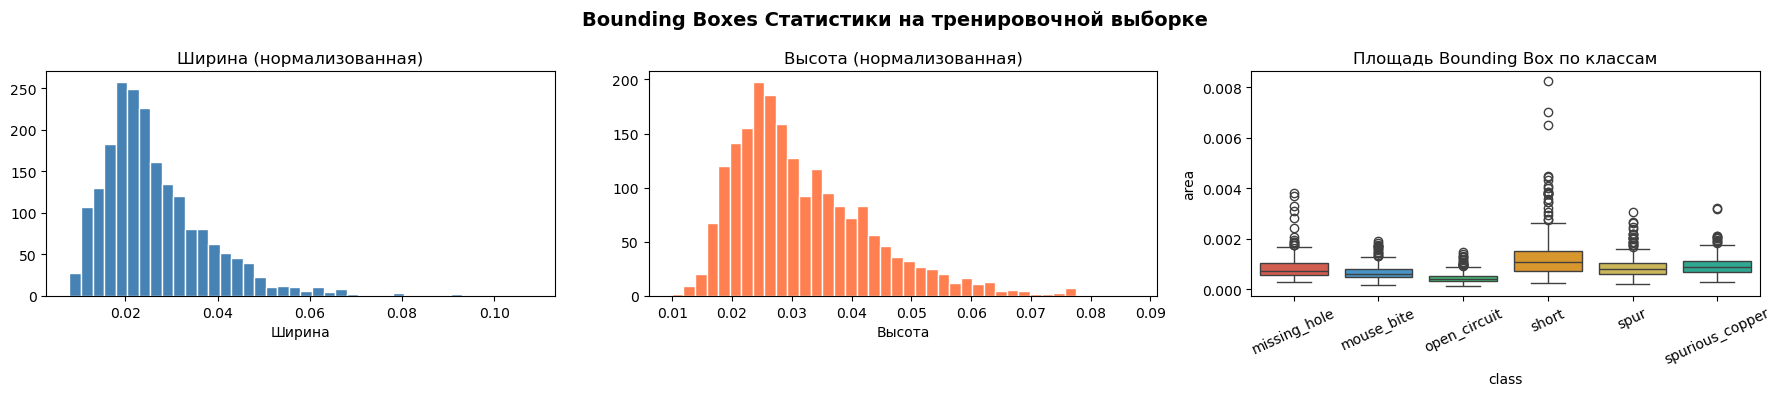

                 width                                                  \
                 count    mean     std     min     25%     50%     75%   
class                                                                    
missing_hole     347.0  0.0250  0.0069  0.0132  0.0205  0.0236  0.0273   
mouse_bite       339.0  0.0236  0.0082  0.0082  0.0177  0.0221  0.0290   
open_circuit     337.0  0.0195  0.0066  0.0079  0.0150  0.0193  0.0228   
short            341.0  0.0324  0.0129  0.0109  0.0234  0.0294  0.0376   
spur             338.0  0.0281  0.0117  0.0099  0.0183  0.0273  0.0362   
spurious_copper  349.0  0.0292  0.0147  0.0096  0.0177  0.0241  0.0394   

                        height          ...                   area          \
                    max  count    mean  ...     75%     max  count    mean   
class                                   ...                                  
missing_hole     0.0609  347.0  0.0326  ...  0.0384  0.0670  347.0  0.0009   
mouse_bite       0.04

In [ ]:
def collect_bbox_stats(labels_dir: Path) -> pd.DataFrame:
    records = []
    for lf in labels_dir.glob('*.txt'):
        for line in open(lf):
            p = line.strip().split()
            if len(p) == 5:
                idx = int(p[0])
                cx, cy, bw, bh = map(float, p[1:])
                records.append({'class': CLASS_NAMES[idx],
                                 'width': bw, 'height': bh, 'area': bw*bh})
    return pd.DataFrame(records)

bbox_df = collect_bbox_stats(DATA_DIR / 'train' / 'labels')

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('Bounding Boxes Статистики на тренировочной выборке',
            fontsize=14, fontweight='bold')

axes[0].hist(bbox_df['width'],  bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Ширина (нормализованная)')
axes[0].set_xlabel('Ширина')

axes[1].hist(bbox_df['height'], bins=40, color='coral', edgecolor='white')
axes[1].set_title('Высота (нормализованная)')
axes[1].set_xlabel('Высота')

sns.boxplot(data=bbox_df, x='class', y='area', ax=axes[2],
            palette=CLASS_COLORS, order=CLASS_NAMES)
axes[2].set_title('Площадь Bounding Box по классам')
axes[2].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.savefig('eda_bbox_stats.png', dpi=150, bbox_inches='tight')
plt.show()

print(bbox_df.groupby('class')[['width','height','area']].describe().round(4))